In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import squarify
from matplotlib_venn import venn2, venn3

dir = "/data/data/Turner/HiCData/ZWJFamilyHiCAfterMapping/outPut/step04_hicpro2juicebox/hicfiles/TAD"

In [2]:
scope = 2

In [3]:
def _venn3(df1, df2, df3, chr=None, excluded_chr=None, resolution=40000):
    if chr != None:
        df1 = df1[df1["track"]==chr]
        df2 = df2[df2["track"]==chr]
        df3 = df3[df3["track"]==chr]
    if excluded_chr != None:
        df1 = df1[df1["track"]!=excluded_chr]
        df2 = df2[df2["track"]!=excluded_chr]
        df3 = df3[df3["track"]!=excluded_chr]

    nums = [0, 0, 0, 0, 0, 0, 0]  # 1, 2, 1&2, 3, 1&3, 2&3, 1&2&3
    for _chr in df1["track"].unique():
        _df1, _df2, _df3 = df1[df1["track"]==_chr], df2[df2["track"]==_chr], df3[df3["track"]==_chr]
        for _, row in _df1.iterrows():
            _p = [0, 0]
            for i in range(0, scope+1):
                if row[1] + i * resolution in _df2.iloc[:, 1].values and _p[0] != 1:
                    _p[0] = 1
                if row[1] - i * resolution in _df2.iloc[:, 1].values and _p[0] != 1:
                    _p[0] = 1

                if row[1] + i * resolution in _df3.iloc[:, 1].values and _p[1] != 1:
                    _p[1] = 1
                if row[1] - i * resolution in _df3.iloc[:, 1].values and _p[1] != 1:
                    _p[1] = 1
            
            if _p[0] == _p[1] == 0:
                nums[0] += 1
            elif _p[0] == 0 and _p[1] == 1:
                nums[4] += 1
            elif _p[0] == 1 and _p[1] == 0:
                nums[2] += 1
            elif _p[0] == _p[1] == 1:
                nums[6] += 1
        
        for _, row in _df2.iterrows():
            _p = [0, 0]
            for i in range(0, scope+1):
                if row[1] + i * resolution in _df1.iloc[:, 1].values and _p[0] != 1:
                    _p[0] = 1
                if row[1] - i * resolution in _df1.iloc[:, 1].values and _p[0] != 1:
                    _p[0] = 1

                if row[1] + i * resolution in _df3.iloc[:, 1].values and _p[1] != 1:
                    _p[1] = 1
                if row[1] - i * resolution in _df3.iloc[:, 1].values and _p[1] != 1:
                    _p[1] = 1

            if _p[0] == _p[1] == 0:
                nums[1] += 1
            elif _p[0] == 0 and _p[1] == 1:
                nums[5] += 1
        
        for _, row in _df3.iterrows():
            _p = [0, 0]
            for i in range(0, scope+1):
                if row[1] + i * resolution in _df1.iloc[:, 1].values and _p[0] != 1:
                    _p[0] = 1
                if row[1] - i * resolution in _df1.iloc[:, 1].values and _p[0] != 1:
                    _p[0] = 1

                if row[1] + i * resolution in _df2.iloc[:, 1].values and _p[1] != 1:
                    _p[1] = 1
                if row[1] - i * resolution in _df2.iloc[:, 1].values and _p[1] != 1:
                    _p[1] = 1

            if _p[0] == _p[1] == 0:
                nums[3] += 1
    
    return nums

def _venn2(df1, df2, chr=None, excluded_chr=None, resolution=40000):
    if chr != None:
        df1 = df1[df1["track"]==chr]
        df2 = df2[df2["track"]==chr]
    if excluded_chr != None:
        df1 = df1[df1["track"]!=excluded_chr]
        df2 = df2[df2["track"]!=excluded_chr]

    nums = [0, 0, 0]  # 1, 2, 1&2
    for _chr in df1["track"].unique():
        _df1, _df2 = df1[df1["track"]==_chr], df2[df2["track"]==_chr]
        for _, row in _df1.iterrows():
            _p = 0
            for i in range(0, scope+1):
                if row[1] + i * resolution in _df2.iloc[:, 1].values and _p != 1:
                    _p = 1
                if row[1] - i * resolution in _df2.iloc[:, 1].values and _p != 1:
                    _p = 1
            
            if _p == 0:
                nums[0] += 1
            else:
                nums[2] += 1
        
        for _, row in _df2.iterrows():
            _p = 0
            for i in range(0, scope+1):
                if row[1] + i * resolution in _df1.iloc[:, 1].values and _p != 1:
                    _p = 1
                if row[1] - i * resolution in _df1.iloc[:, 1].values and _p != 1:
                    _p = 1

            if _p == 0:
                nums[1] += 1
    
    return nums

In [4]:
TAD_naive = {
    "F": pd.read_csv(os.path.join(dir, "F-naive/F-naive_TAD.bed"), sep="\t"),
    "M": pd.read_csv(os.path.join(dir, "M-naive/M-naive_TAD.bed"), sep="\t"),
    "Z": pd.read_csv(os.path.join(dir, "Z-naive/Z-naive_TAD.bed"), sep="\t"),
}
display(TAD_naive["F"]["track"].unique())

for key in TAD_naive:
    TAD_naive[key]['location'] = TAD_naive[key].iloc[:, 0].astype(str) + "_" + TAD_naive[key].iloc[:, 1].astype(str) + "_" + TAD_naive[key].iloc[:, 2].astype(str)

display(_venn3(TAD_naive["Z"], TAD_naive["F"], TAD_naive["M"], excluded_chr="chrX"))
display(_venn3(TAD_naive["Z"], TAD_naive["F"], TAD_naive["M"], "chrX"))

array(['chr1', 'track', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7',
       'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14',
       'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21',
       'chr22', 'chrX'], dtype=object)

[180, 159, 107, 116, 152, 128, 2956]

[14, 16, 15, 10, 6, 8, 124]

In [5]:
TAD_IgDn = {
    "F": pd.read_csv(os.path.join(dir, "F-IgD-/F-IgD-_TAD.bed"), sep="\t"),
    "M": pd.read_csv(os.path.join(dir, "M-IgD-/M-IgD-_TAD.bed"), sep="\t"),
    "Z": pd.read_csv(os.path.join(dir, "Z-IgD-/Z-IgD-_TAD.bed"), sep="\t"),
}

for key in TAD_IgDn:
    TAD_IgDn[key]['location'] = TAD_IgDn[key].iloc[:, 0].astype(str) + "_" + TAD_IgDn[key].iloc[:, 1].astype(str) + "_" + TAD_IgDn[key].iloc[:, 2].astype(str)

display(_venn3(TAD_IgDn["Z"], TAD_IgDn["F"], TAD_IgDn["M"], excluded_chr="chrX"))
display(_venn3(TAD_IgDn["Z"], TAD_IgDn["F"], TAD_IgDn["M"], "chrX"))

[174, 180, 113, 126, 164, 129, 3004]

[10, 22, 14, 6, 7, 2, 123]

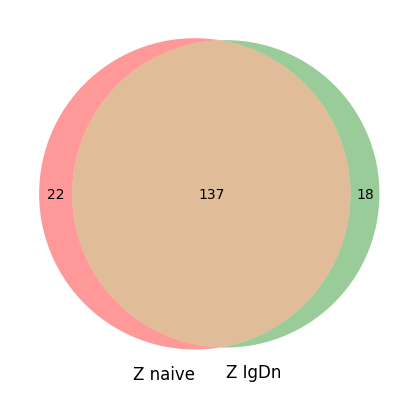

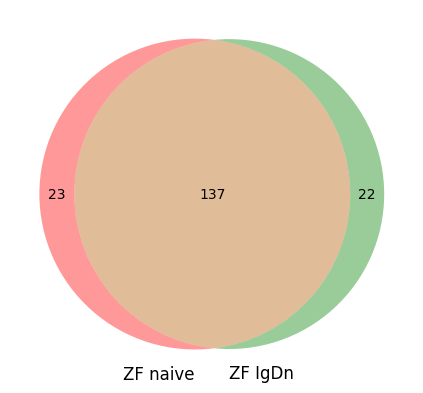

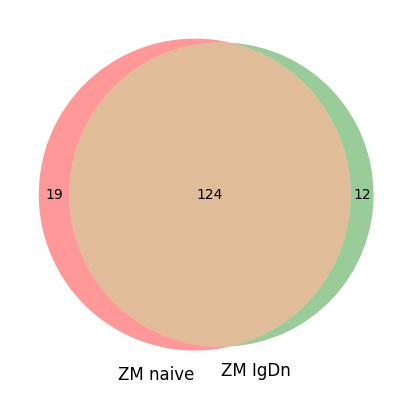

In [6]:
venn2(subsets=_venn2(TAD_naive["Z"], TAD_IgDn["Z"], "chrX"), set_labels=('Z naive', 'Z IgDn'))
plt.savefig('Z_naive.TAD.diff.Z_IgDn.X.pdf', format='pdf', bbox_inches='tight')
plt.show()

venn2(subsets=_venn2(TAD_naive["F"], TAD_IgDn["F"], "chrX"), set_labels=('ZF naive', 'ZF IgDn'))
plt.savefig('ZF_naive.TAD.diff.ZF_IgDn.X.pdf', format='pdf', bbox_inches='tight')
plt.show()

venn2(subsets=_venn2(TAD_naive["M"], TAD_IgDn["M"], "chrX"), set_labels=('ZM naive', 'ZM IgDn'))
plt.savefig('ZM_naive.TAD.diff.ZM_IgDn.X.pdf', format='pdf', bbox_inches='tight')
plt.show()

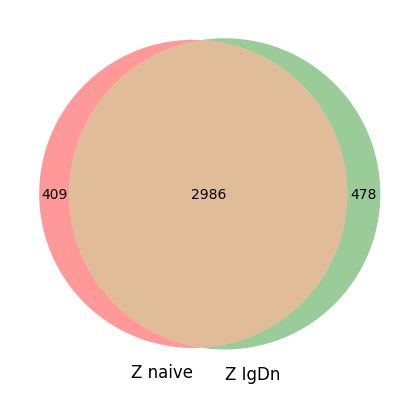

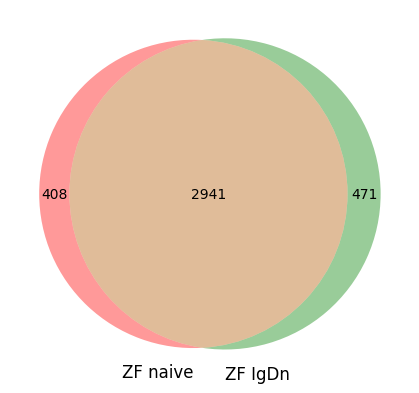

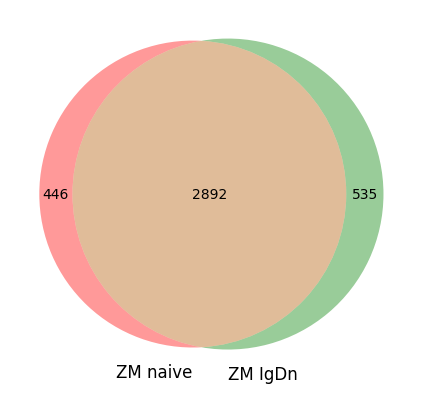

In [7]:
venn2(subsets=_venn2(TAD_naive["Z"], TAD_IgDn["Z"], excluded_chr="chrX"), set_labels=('Z naive', 'Z IgDn'))
plt.savefig('Z_naive.TAD.diff.Z_IgDn.auto.pdf', format='pdf', bbox_inches='tight')
plt.show()

venn2(subsets=_venn2(TAD_naive["F"], TAD_IgDn["F"], excluded_chr="chrX"), set_labels=('ZF naive', 'ZF IgDn'))
plt.savefig('ZF_naive.TAD.diff.ZF_IgDn.auto.pdf', format='pdf', bbox_inches='tight')
plt.show()

venn2(subsets=_venn2(TAD_naive["M"], TAD_IgDn["M"], excluded_chr="chrX"), set_labels=('ZM naive', 'ZM IgDn'))
plt.savefig('ZM_naive.TAD.diff.ZM_IgDn.auto.pdf', format='pdf', bbox_inches='tight')
plt.show()